# Lab:4 Single Layer Perceptron and Multi-Layer Perceptron

### 1. Imports

In [32]:
import numpy as np
import matplotlib.pyplot as plt

### Task 1 — Single Layer Perceptron (from scratch)
#### Objective: Train a perceptron to classify points based on a linear boundary using Python from first principles.
##### a.	Setup Python Environment
##### b.	Define Perceptron Function
##### c.	Generate Synthetic Training Data
##### d.	Train with Perceptron Learning Rule
##### e.	Visualize Decision Boundary

### 2. Linearly Separable Dataset

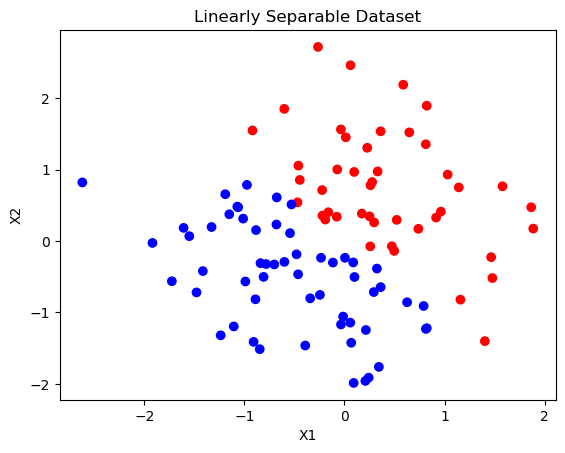

In [33]:
np.random.seed(42)
# Create 100 points with 2 coordinates (X1, X2) each
X = np.random.randn(100, 2)
# Label points: if X1 + X2 > 0, label is 1, otherwise 0
y = np.where(X[:, 0] + X[:, 1] > 0, 1, 0)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Linearly Separable Dataset")
plt.show()

### Single Layer Perceptron (SLP)

A Single Layer Perceptron is a linear binary classifier.

It computes:
    y = f(wX + b)
Where:
- w = weights  
- b = bias  
- f = step activation function  
The perceptron updates weights using:
    w = w + η (y_true - y_pred) X
It can only classify **linearly separable data**.

### 3. Define Perceptron Step activation function

In [34]:
class Perceptron:
    def __init__(self, learning_rate=0.1, epochs=100):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    # Step Activation Function
    def activation(self, x):
        return np.where(x >= 0, 1, 0)

    # Training Function
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.epochs):
            for i in range(n_samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                y_pred = self.activation(linear_output)

                update = self.lr * (y[i] - y_pred)
                self.weights += update * X[i]
                self.bias += update

    # Prediction
    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation(linear_output)


In [60]:
p = Perceptron(learning_rate=0.1, epochs=20)
p.fit(X, y)

predictions = model.predict(X)
accuracy = np.mean(predictions == y)

print("Training Accuracy:", accuracy)
print("Weights:", model.weights)
print("Bias:", model.bias)


Training Accuracy: 1.0
Weights: [0.32022487 0.29293239]
Bias: 0.0


### 4. Single Layer Perceptron Decision Boundary

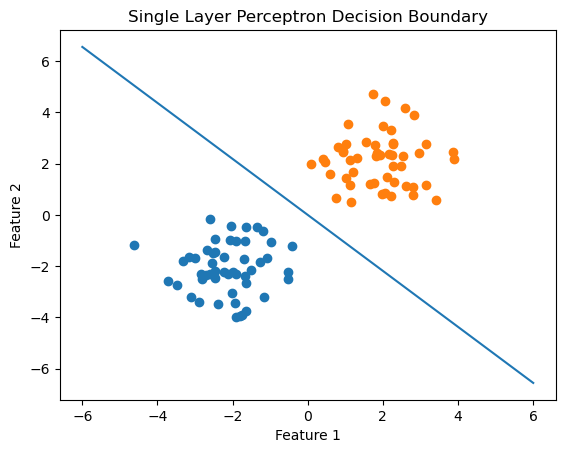

In [61]:
# Plot points
plt.scatter(X0[:,0], X0[:,1])
plt.scatter(X1[:,0], X1[:,1])

# Decision boundary
x_values = np.linspace(-6, 6, 100)
y_values = -(model.weights[0]/model.weights[1]) * x_values - model.bias/model.weights[1]

plt.plot(x_values, y_values)

plt.title("Single Layer Perceptron Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Task 2 — Multi-Layer Perceptron (MLP)
#### Objective: Build an MLP classifier using NumPy (from scratch) to learn non-linear decision boundaries.
#### (For context: an MLP adds “hidden layers” and trains using backpropagation.)
##### a.	Define Network Architecture
##### For simplicity: 
- Input layer: 2 neurons
- Hidden layer: 4 neurons (ReLU activation)
- Output layer: 1 neuron (sigmoid)
##### b.	Define Activation Functions
##### c.	Initialize Weights & Biases
##### d.	Train with Backpropagation
##### e.	Evaluate the Model

In [62]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
def sigmoid_deriv(a):
    return a * (1 - a)
def relu(z):
    return np.maximum(0, z)
def relu_deriv(z):
    return (z > 0).astype(float)

### Multi-Layer Perceptron (MLP)
A Multi-Layer Perceptron contains:
- Input layer
- One or more hidden layers
- Output layer
MLP uses non-linear activation functions (e.g., sigmoid) and learns using backpropagation.
This allows it to model complex, non-linear decision boundaries.

In [ ]:
def generate_xor(n=200):
    X = np.random.randn(n, 2)
    y = (X[:, 0] * X[:, 1] > 0).astype(int)
    return X, y

X_xor, y_xor = generate_xor()

### 5. Define MLP

In [64]:
class MLP:
    def __init__(self, input_size=2, hidden_size=4, lr=0.1, epochs=500):
        self.lr = lr
        self.epochs = epochs

        self.W1 = np.random.randn(hidden_size, input_size) * 0.1
        self.b1 = np.zeros(hidden_size)

        self.W2 = np.random.randn(1, hidden_size) * 0.1
        self.b2 = np.zeros(1)

    def forward(self, X):
        self.Z1 = X @ self.W1.T + self.b1
        self.A1 = relu(self.Z1)

        self.Z2 = self.A1 @ self.W2.T + self.b2
        self.A2 = sigmoid(self.Z2)

        return self.A2

    def backward(self, X, y):
        m = len(X)
        y = y.reshape(-1, 1)

        dZ2 = self.A2 - y
        dW2 = dZ2.T @ self.A1 / m
        db2 = np.sum(dZ2, axis=0) / m

        dA1 = dZ2 @ self.W2
        dZ1 = dA1 * relu_deriv(self.Z1)
        dW1 = dZ1.T @ X / m
        db1 = np.sum(dZ1, axis=0) / m

        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def fit(self, X, y):
        losses = []
        for _ in range(self.epochs):
            y_pred = self.forward(X)
            loss = -np.mean(
                y * np.log(y_pred + 1e-8) + (1 - y) * np.log(1 - y_pred + 1e-8)
            )
            losses.append(loss)
            self.backward(X, y)
        return losses

    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int).flatten()

In [65]:
def plot_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.5)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
    plt.title(title)
    plt.show()

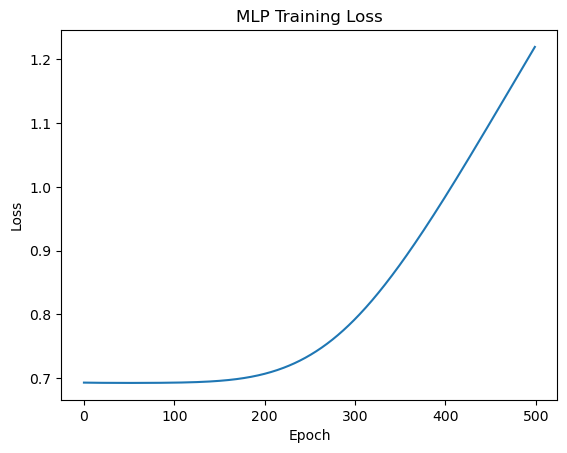

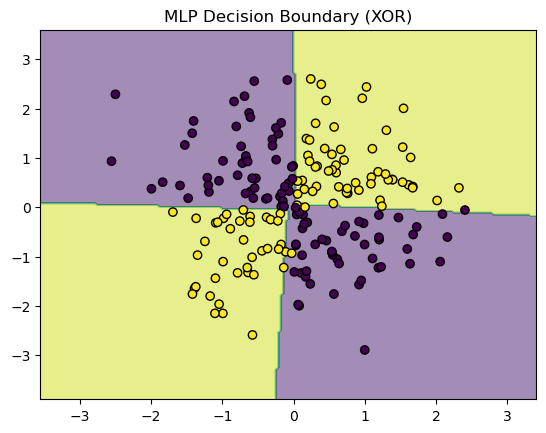

In [66]:
mlp = MLP(hidden_size=8, lr=0.1, epochs=500)
losses = mlp.fit(X_xor, y_xor)

plt.plot(losses)
plt.title("MLP Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plot_boundary(mlp, X_xor, y_xor, "MLP Decision Boundary (XOR)")

### Task 3 — Perform following tasks:
#### 1.	Compare single layer vs MLP on linearly separable vs non-linear data (e.g., XOR). 
#### 2.	Explore how hidden layer size impacts learning.
#### 3.	Plot loss over training epochs.

### XOR Problem
The XOR dataset is not linearly separable.
Truth table:

| X1 | X2 | Output |
|----|----|--------|
| 0  | 0  | 0 |
| 0  | 1  | 1 |
| 1  | 0  | 1 |
| 1  | 1  | 0 |

A single straight line cannot separate this data.
An MLP with hidden neurons is required to solve it.

In [67]:
# Linearly separable dataset
X_linear = np.array([[1,1],
                     [2,1],
                     [1,2],
                     [4,4],
                     [5,4],
                     [4,5]])

y_linear = np.array([0,0,0,1,1,1])

In [68]:
X_xor = np.array([[0,0],
                  [0,1],
                  [1,0],
                  [1,1]])

y_xor = np.array([[0],
                  [1],
                  [1],
                  [0]])


In [74]:
hidden_size = 1
hidden_size = 2
hidden_size = 4
hidden_size = 8

In [75]:
losses = []

for epoch in range(epochs):

    Z1 = np.dot(X_xor, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    loss = -np.mean(y_xor * np.log(A2 + 1e-8) + 
                    (1 - y_xor) * np.log(1 - A2 + 1e-8))

    losses.append(loss)

    dZ2 = A2 - y_xor
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = np.dot(X_xor.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

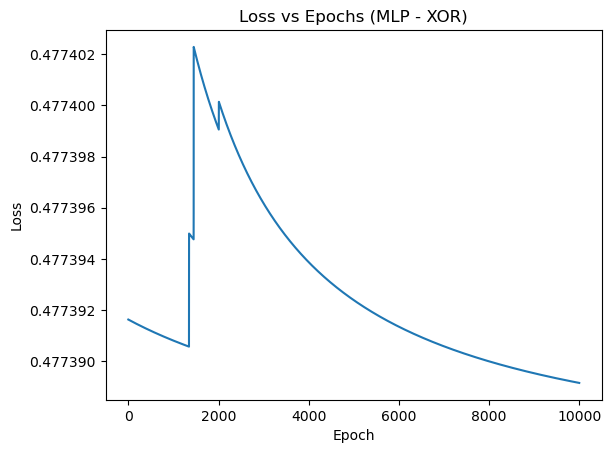

In [76]:
plt.plot(losses)
plt.title("Loss vs Epochs (MLP - XOR)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [77]:
def accuracy(model, X, y):
    return np.mean(model.predict(X) == y)


print("Perceptron on Linear Data:", accuracy(p, X_linear, y_linear))
print("MLP on Linear Data:", accuracy(mlp, X_linear, y_linear))
print("Perceptron on XOR Data:", accuracy(p, X_xor, y_xor))
print("MLP on XOR Data:", accuracy(mlp, X_xor, y_xor))

Perceptron on Linear Data: 0.5
MLP on Linear Data: 0.5
Perceptron on XOR Data: 0.5
MLP on XOR Data: 0.5


### Concepts

#### 1. Backpropagation

Backpropagation is used to train MLPs.

Steps:
1. Forward pass (compute output)
2. Compute error
3. Calculate gradients
4. Update weights using gradient descent

This minimizes the loss function.

#### 2. Loss and Accuracy

Loss measures how far predictions are from true values.

Accuracy measures:

    Accuracy = Correct Predictions / Total Samples

Loss curve helps analyze convergence behavior of the model.

#### Conclusion

- Single Layer Perceptron works only for linearly separable data.
- It fails on XOR due to linear limitation.
- Multi-Layer Perceptron solves non-linear problems using hidden layers.
- Hidden neurons increase learning capacity.